In [53]:
from __future__ import annotations#used for type hinting
import re
import json
import operator
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,List,Optional,Annotated
from pydantic import  BaseModel,Field
from langgraph.types import Send#used for dynamic routing inside a graph
from langchain_core.messages import HumanMessage,SystemMessage
from langchain_community.tools.tavily_search import TavilySearchResults#used to conduct web seach 
from pathlib import Path
from datetime import date, datetime, timedelta
from dotenv import load_dotenv
load_dotenv()

True

default_factory=List->If user does not provide bullets, create a new empty list [].

In [54]:
class CriticOutput(BaseModel):
    decision: Literal["accept", "revise", "rewrite"]
    rating: int = Field(..., ge=0, le=10)
    key_issues: List[str] = Field(default_factory=list)
    improvement_needed: bool = Field(default=False)

In [55]:
class Task(BaseModel):
    id:int
    title:str
    goal:str=Field(...,description="One sentence describing what the reader should be able to do/understand after this section.")
    bullets:List[str]=Field(...,
                            min_length=3,#minimum items in the list
                            max_length=6,#max items in the list
                            description="3–6 concrete, non-overlapping subpoints to cover in this section.")
    target_words:int=Field(...,description="Target word count for this section (120–550).")
    tags:List[str]=Field(...,default_factory=list)
    requires_research: bool = False
    requires_citations:bool=False
    requires_code:bool
class Plan(BaseModel):
    blog_title:str
    audience: str
    tone:str
    #allowed vlaues inside the list (default value=explainer)
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints:List[str]=Field(default_factory=list)
    task:List[Task]
class EvidenceItem(BaseModel):#extract data from tavily search in particular format
    title:str
    url:str
    published_at:Optional[str]=None#default value is none
    snippet:Optional[str]=None#main content from tavily search
    source:Optional[str]=None

class EvidencePack(BaseModel):
    evidence:List[EvidenceItem]=Field(default_factory=list)

class RouterDecision(BaseModel):
    needs_research:bool
    mode:Literal["closed_book", "hybrid", "open_book"]
    reason:str
    queries:List[str]=Field(default_factory=list)
    max_result_per_query:int=Field(5,description="How many results to fetch per query (3–8).")


#=Field(5,)means that the default value is 5    

In [56]:
class State(TypedDict):
    topic: str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    as_of: str
    recency_days: int
    sections: Annotated[List[tuple[int, str]], operator.add]
    final_md:str
    final: str
    critic: Optional[CriticOutput]
    compressed_query:Optional[str]
    final_search_results: Optional[List[dict]]

In [57]:
llm=ChatOllama(model="llama3.1:8b")

In [58]:
router_prompt= """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- For open_book weekly roundup, include queries that reflect the last 7 days constraint.
"""
def router_node(state:State)->dict:
    topic=state['topic']
    decider_llm=llm.with_structured_output(RouterDecision)
    decision=decider_llm.invoke(
        [
            SystemMessage(content=router_prompt),
            HumanMessage(content=f"Topic:{topic}\n As of date{state['as_of']}")
        ]
    )
    if decision.mode=="open_book":
        recency_days = 7
    elif decision.mode=="hybrid":
        recency_days=45
    else:
        recency_days=3650
    return{
        "needs_research": decision.needs_research,
        "mode":decision.mode,
        "queries":decision.queries,
        "recency_days": recency_days,
    }
def router_next(state:State)->str:
    return "research" if state["needs_research"] else "orchestrator"

In [59]:
# Research Tavily
# default value -> for search result = 5
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    """
    Uses TavilySearchResults if installed and TAVILY_API_KEY is set.
    Returns list of dict with common fields. Note: published date is often missing.
    """
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    # Handle Tavily response if returned as dict
    if isinstance(results, dict):
        results = results.get("results", [])
    elif results is None:
        results = []

    normalized: List[dict] = []

    for r in results:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )

    return normalized


def _iso_to_date(s: Optional[str]) -> Optional[date]:
    # convert string date to date object
    if not s:
        return None
    try:
        return date.fromisoformat(s[:10])
    except Exception:
        return None


# research node
RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- Extract/normalize published_at as ISO (YYYY-MM-DD) if you can infer it from title/snippet.
  If you can't infer a date reliably, set published_at=null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""


def research_node(state: State) -> dict:
    queries = state.get("queries", [])[:10]
    max_results = 6
    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)

    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(
                content=(
                    f"As-of date: {state['as_of']}\n"
                    f"Recency days: {state['recency_days']}\n\n"
                    f"Raw results:\n{json.dumps(raw_results, indent=2)}"
                )
            )
        ]
    )

    dupe = {}

    for e in pack.evidence:
        if e.url and e.url not in dupe:
            dupe[e.url] = e

    evidence = list(dupe.values())

    return {"evidence": evidence}

In [60]:
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Flexibility:
- Do NOT use a fixed taxonomy unless it naturally fits.
- You may tag tasks (tags field), but tags are flexible.
Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book (weekly news roundup):
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections (no scraping/RSS/how to fetch news) unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient fresh sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""
def orchestrator_node(state: State) -> dict:
    planner=llm.with_structured_output(Plan)
    evidence=state.get("evidence",[])
    mode=state.get("mode","closed_book")
  # Force blog_kind for open_book
    forced_kind="news_roundup" if mode== "open_book" else None
    plan=planner.invoke(
        [
        SystemMessage(content=ORCH_SYSTEM),
        HumanMessage(content=
                     (f"Topic:{state['topic']}\n"
                     f"Mode:{mode}\n"
                     f"As-of: {state['as_of']} (recency_days={state['recency_days']})\n"
                     f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                     f"Evidence (ONLY use for fresh claims; may be empty):\n"
                     f"{[e.model_dump() for e in evidence][:16]}\n\n"
                     f"Instruction: If mode=open_book, your plan must NOT drift into a tutorial."
                     ))
        ]    
    )
# Ensure open_book forces the kind even if model forgets
    if forced_kind:
        plan.blog_kind = "news_roundup"

    return {"plan": plan}
def fanout(state:State):#list of Send.
    assert state['plan'] is not None# assert checks that plan is not None
    return [ #state->plan->list[task] task is itself a pydantic object
        Send(
            "worker",
            {
                "task":task.model_dump(),#convert pydantic object into dictionay sending task to the worker node as a dictionary(unpack it )
                "topic":state['topic'],
                "mode":state['mode'],
                "as_of":state['as_of'],
                "recency_days":state['recency_days'],
                'Plan':state["plan"].model_dump(),
                 # evidence: List[EvidenceItem]
                "Evidence":[e.model_dump() for e in state.get("evidence",[])]##evidence: List[EvidenceItem]
            },
            
        )
        for task in state['plan'].task
    ]

In [61]:
#building the worker node
worker_prompt=""" You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard (prevents mid-blog topic drift):
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book (weekly news):
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true (hybrid sections):
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning (concepts, intuition) is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""
#. **=>unpacking dictionary 
def worker_node(payload: dict) -> dict:
    task=Task(**payload["task"])#unpack the dictionary        #task is dictionary(intially pydantic object)
    plan=Plan(**payload["Plan"])#unpack the dictionary
    evidence=[EvidenceItem(**e) for e in payload.get("Evidence",[])]
    topic=payload['topic']
    mode=payload.get("mode",'closed_book')# if we fail then it is closed_book (default-mode=closed_book)
    as_of=payload['as_of']
    recency_days = payload.get("recency_days")

    #task=>id,title,goal,bullets,target_words,tags,requires_reseach,requires_citation,requires_code
    bullets_text = "\n- " + "\n- ".join(task.bullets)
    evidence_text=""
    evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )
    section_md=llm.invoke(
        [
            SystemMessage(content=worker_prompt),
            HumanMessage(content=(
                f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {as_of} (recency_days={recency_days})\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
            )
            )
        ]
    ).content.strip()#extract content and remove the white trailing spaces


    return {"sections": [(task.id, section_md)]}

In [62]:
def reducer_node(state:State)->dict:
    plan=state['plan']
    if not plan:
         raise ValueError("Reducer called without a plan.")
    #sections has id and section_md
    ordered_sections=[md for _,md in sorted(state['sections'],key=lambda x:x[0])]#sort on the basis of task id 
  #we sot because the worker are workinhg || and we dont know which worker finished first
         #key (Optional): A function that serves as a basis for sort comparison (e.g., key=len to sort strings by length). so we sort on basis of task_id (task_id,section_md)
    body="\n".join(ordered_sections).strip()  
    final_md = f"# {plan.blog_title}\n\n{body}\n"
    return {"final_md": final_md}
    


In [63]:

critic_prompt="""You are a professional editorial critic responsible for reviewing blog posts across any domain (technology, business, education, lifestyle, opinion, etc.).

Your job is to evaluate the quality of a blog post and provide structured, objective feedback.

You do NOT rewrite the blog unless explicitly asked. You only assess and critique.

---

## Evaluation Criteria

### 1. Clarity
- Is the writing easy to understand?
- Are ideas expressed clearly without confusion?
- Are sentences well-structured?

### 2. Structure & Organization
- Does the blog have a logical flow (introduction → body → conclusion)?
- Are sections properly organized and distinct?
- Is there a clear progression of ideas?

### 3. Content Quality
- Is the content meaningful and informative?
- Does it avoid fluff or unnecessary filler?
- Does it stay relevant to the topic?

### 4. Depth & Insight
- Does the blog go beyond surface-level explanation?
- Are ideas explained with sufficient depth?
- Does it show understanding rather than repetition?

### 5. Coherence & Flow
- Do paragraphs connect smoothly?
- Are transitions natural?
- Is there repetition or redundancy?

### 6. Engagement & Readability
- Is the blog engaging to read?
- Does it maintain reader interest?
- Is tone appropriate for a general audience?

---

## Critical Rules

- Be honest and strict in evaluation.
- Do not assume the blog is good by default.
- Prefer “needs improvement” if quality is borderline.
- Focus on readability and structure over domain expertise.

---

## Output Format (STRICT JSON)

Return ONLY valid JSON:

{
  "decision": "accept" | "revise",
  "overall_score": 0-10,
  "strengths": [
    "what is good about the blog"
  ],
  "weaknesses": [
    "what is wrong or unclear"
  ],
  "structure_issues": true | false,
  "clarity_issues": true | false,
  "redundancy_detected": true | false,
  "depth_issues": true | false,
  "suggestions": [
    "actionable improvements"
  ],
  "final_comment": "1-3 sentence overall critique"
}

---

## Decision Rules

- If writing is unclear or confusing → revise
- If structure is weak or disorganized → revise
- If content is shallow or repetitive → revise
- Only accept if the blog is clear, structured, and readable

---

You are the final editorial reviewer before publication."""
critic_llm=llm.with_structured_output(CriticOutput)


In [64]:
def critic_llm_node(state: State):

    response = critic_llm.invoke([
        SystemMessage(content=critic_prompt),

        HumanMessage(content=
            f"""
Topic: {state.get('topic')}

Plan:
{state['plan'].model_dump() if state.get('plan') else None}

Audience: {state['plan'].audience if state.get('plan') else None}

Constraints: {state['plan'].constraints if state.get('plan') else None}

Final Blog:
{state.get('final_md')}

Evidence:
{state.get('evidence', [])}

Evaluation Task:
- Check relevance to topic
- Check completeness vs plan
- Check clarity and structure
- Detect repetition or hallucination
- Decide if revision is needed
"""
        )
    ])
 
    return {"critic": response}

In [65]:
def rerouter(state:State):
    critical_output=state.get("critic")
    if critical_output is None:
        return "end"
    if critical_output.decision == "accept" and critical_output.rating >= 7:
        return "end"
    return "rewrite"

Field(...)#must provide a value =>if no vlaue error

In [66]:
#rewriting subgraph
class websearchDecision(BaseModel):
    web_search: bool = Field(default=True)


In [67]:
websearch_llm=llm.with_structured_output(websearchDecision)

In [68]:
websearch_prompt="""You are a routing module inside an AI blog rewriting system.

Your task is to decide whether a web search is required to improve the given blog.

You will be given:
- Blog title
- Final blog content (final_md)
- Topic
- Audience

---

## YOUR TASK

Read the blog carefully and decide:

Does improving this blog require external web search?

External web search is ONLY needed if:
- The blog is missing recent or up-to-date information
- The blog contains claims that may require verification
- The blog would benefit from real-world examples, tools, or current trends
- The topic is fast-changing (AI models, frameworks, news, tech updates)
---
## NO WEB SEARCH is needed if:
- The blog only needs clarity improvements
- The blog needs restructuring or better explanation
- The content is based on general knowledge
- The issues can be fixed using internal reasoning

---

## DECISION RULE

Be conservative:
Only choose web search if it is clearly necessary.

---

## OUTPUT FORMAT (STRICT)

Return ONLY valid JSON matching this schema:

{
  "web_search": true | false
}
---

## FINAL RULES

- Do NOT explain your answer
- Do NOT rewrite the blog
- Do NOT add extra fields
- Output ONLY the JSON object"""
def check_websearch_node(state: State) -> dict:
  output=websearch_llm.invoke([
      SystemMessage(content=websearch_prompt),
      HumanMessage(content=
          f"""
  Blog title: {state.get('plan').blog_title if state.get('plan') else None}
  Final blog content:
  {state.get('final_md')}
  Topic: {state.get('topic')}
  Audience: {state.get('plan').audience if state.get('plan') else None}
  """
      )
  ])
  return {"web_search": output.web_search}

In [69]:
class WebSearchQueries(BaseModel):
    queries: List[str]

In [70]:
websearch_llm_final=llm.with_structured_output(WebSearchQueries)

In [71]:
class compress(BaseModel):
    compressed_query:str=Field(...,description="blog convereted into query to do web search")

In [72]:
compress_llm=llm.with_structured_output(compress)

In [73]:
compress_blog_query="""You are a web search query compression agent.

Your job is to read a blog and generate exactly ONE highly effective web search query that captures the blog’s core topic and helps retrieve the most relevant, recent, and authoritative information.

Input:

* blog_title
* final_md

Task:

1. Read the blog title and content carefully.
2. Identify the blog’s primary topic, key entities, and most important factual or technical areas.
3. Compress the entire blog into one optimized search query for web search.
4. The query should maximize retrieval quality for:

   * factual verification
   * recent updates
   * official documentation
   * technical accuracy

Rules:

* Generate exactly ONE query.
* Query must be concise but information-dense.
* Prioritize the most important topic of the blog.
* Include important keywords, tools, frameworks, companies, or technologies if relevant.
* Add recency indicators (such as 2025 or 2026) if the topic is fast-changing.
* Avoid unnecessary filler words.
* Do not explain your reasoning.

Good examples:

* LangGraph multi-agent workflow architecture best practices 2026
* Snowflake data warehouse architecture pricing and performance optimization
* OpenAI API latest model updates and pricing 2026

Bad examples:

* AI agents
* Snowflake tutorial
* OpenAI news

Output:
Return only a JSON object matching this schema.

{
"compressed_query": "your search query here"
}
"""

In [74]:
def blog_compress_query(state:State):
    output = compress_llm.invoke([
    SystemMessage(content=compress_blog_query),
    HumanMessage(content=
        f"Blog title: {state.get('plan').blog_title if state.get('plan') else None}\n"
        f"Final blog content:\n{state.get('final_md')}"
    )
])
    return{"compressed_query": output.compressed_query}

In [75]:
def websearch(state:State):
    """
    Uses TavilySearchResults if installed and TAVILY_API_KEY is set.
    Returns list of dict with common fields. Note: published date is often missing.
    """
    max_results=5
    query=state.get("compressed_query")
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})
    if isinstance(results,dict):
        results=results.get("results",[])
    elif results is None:
        results=[]
    
    normalized: List[dict] = []

    for r in results:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )

    return {"final_search_results": normalized}

In [76]:
rewrite_prompt="""You are an expert blog rewriting system.

Your job is to improve an existing blog using:
1. Critic feedback
2. Web search results

You will receive:
- Blog topic
- Audience
- Original blog content
- Critic feedback
- Relevant web search results

TASK:
Rewrite the blog to improve:
- clarity
- structure
- completeness
- factual accuracy
- depth

RULES:
- Preserve the original blog’s main intent and topic.
- Fix weaknesses identified by the critic.
- Use web search results only if relevant.
- Improve explanations where needed.
- Remove repetition and fluff.
- Make the writing clearer and more structured.
- Add useful factual information if search results help.
- Do NOT hallucinate facts.
- If using external facts, rely only on provided search results.

OUTPUT RULES:
- Return only the improved blog in markdown.
- No explanations.
- No extra commentary"""

In [77]:
def final_rewrite_node(state:State):
    search_result=state.get("final_search_results",[])
    critic=state.get("critic")
    search_text="\n".join(
        [
            f"Title: {r['title']}\nURL: {r['url']}\nSnippet: {r['snippet']}\n"
            for r  in search_result
        ]
    )
    output=llm.invoke(
        [
SystemMessage(content=(rewrite_prompt)),
HumanMessage(content=(
f"Topic:{state['topic']}"
f"Audience:{state['plan'].audience if state.get("Plan") else None}"
f"Original_Blog:{state['final_md']}"
f"Search_text_blog:{search_text}"
f"Critic:{state['critic'].key_issues}"
)
)
        ]
    )
    improved_blog=output.content.strip()
    blog_title=state['plan'].blog_title
    filename = f"{blog_title}_improved.md"
    Path(filename).write_text(improved_blog,encoding="utf-8")

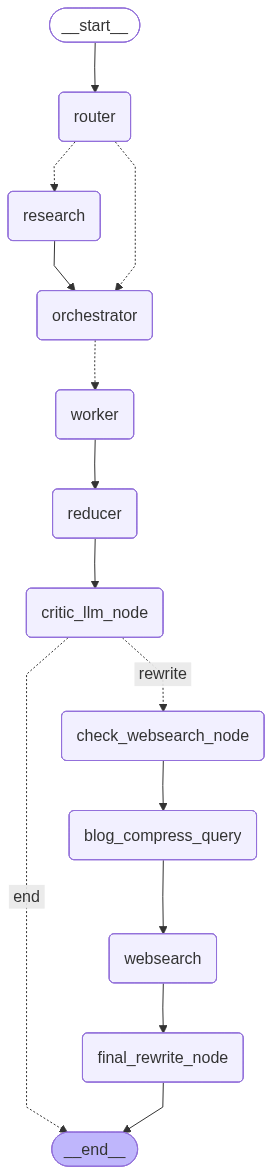

In [78]:

g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)
g.add_node("critic_llm_node",critic_llm_node)
g.add_node("check_websearch_node",check_websearch_node)
g.add_node("blog_compress_query",blog_compress_query)
g.add_node("websearch",websearch)
g.add_node("final_rewrite_node",final_rewrite_node)





g.add_edge(START, "router")
g.add_conditional_edges("router", router_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", "critic_llm_node")
g.add_conditional_edges("critic_llm_node",rerouter,{"end":END,"rewrite":"check_websearch_node"    
})
g.add_edge("check_websearch_node","blog_compress_query")
g.add_edge("blog_compress_query","websearch")
g.add_edge('websearch','final_rewrite_node')
g.add_edge("final_rewrite_node",END)



app = g.compile()

app

list → built-in Python type


List → typing hint from typing module (older style)

In [ ]:
result = app.invoke({
    "topic": "Explain CNN",
    "as_of": "2026-06-27",
    "sections": []
})